# Notebook 00 — Data Preprocessing

This notebook documents every preprocessing step applied to the raw SLTDA dataset
before any model is trained. This is the foundation of the entire pipeline.

Steps covered:
1. Load raw data and inspect structure
2. Handle missing values and data types
3. Handle duplicate records
4. Aggregate country-level to monthly total
5. Handle COVID-19 border closure period
6. Stationarity testing (ADF test)
7. Seasonality decomposition
8. Train/test split
9. Feature engineering for ML models
10. Save cleaned data


In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams['figure.figsize'] = (14, 5)
print("Libraries loaded successfully.")

Libraries loaded successfully.


## Step 1: Load raw data and inspect structure

In [2]:
# Load raw SLTDA dataset
df = pd.read_csv('../data/Tourism_MOM_Dataset.csv')

# Strip whitespace from column names (common data quality issue)
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
print("\nColumn names:", list(df.columns))
print("\nData types BEFORE cleaning:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (20472, 6)

Column names: ['Year', 'Country', 'Continent', 'Sub Continent', 'Date', 'Arrivals']

Data types BEFORE cleaning:
Year              int64
Country          object
Continent        object
Sub Continent    object
Date             object
Arrivals         object
dtype: object

First 5 rows:


,Year,Country,Continent,Sub Continent,Date,Arrivals
0,2018,AFGHANISTAN,Asia,South Asia,2018/01/31,83
1,2018,AFGHANISTAN,Asia,South Asia,2018/02/28,150
2,2018,AFGHANISTAN,Asia,South Asia,2018/03/31,112
3,2018,AFGHANISTAN,Asia,South Asia,2018/04/30,40
4,2018,AFGHANISTAN,Asia,South Asia,2018/05/31,108


## Step 2: Handle data types and missing values

In [3]:
# Convert Arrivals to numeric — coerce turns non-numeric to NaN
df['Arrivals'] = pd.to_numeric(df['Arrivals'], errors='coerce')

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Strip country name whitespace
df['Country'] = df['Country'].str.strip()

print("Data types AFTER cleaning:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nRows with null Arrivals:", df['Arrivals'].isnull().sum())

# Drop rows where Arrivals is NaN (genuinely missing, not COVID)
df_clean = df.dropna(subset=['Arrivals'])
print(f"\nRows after dropping null Arrivals: {len(df_clean)} (removed {len(df)-len(df_clean)} rows)")

Data types AFTER cleaning:
Year                      int64
Country                  object
Continent                object
Sub Continent            object
Date             datetime64[ns]
Arrivals                float64
dtype: object

Missing values per column:
Year                0
Country             0
Continent           0
Sub Continent       0
Date                0
Arrivals         3575
dtype: int64

Rows with null Arrivals: 3575

Rows after dropping null Arrivals: 16897 (removed 3575 rows)


## Step 3: Check for duplicates

In [4]:
# Check for duplicate country-date combinations
duplicates = df_clean.duplicated(subset=['Country', 'Date']).sum()
print(f"Duplicate country-date pairs: {duplicates}")

# Check date range
print(f"\nDate range in raw data: {df_clean['Date'].min().date()} to {df_clean['Date'].max().date()}")
print(f"Unique countries: {df_clean['Country'].nunique()}")
print(f"Unique months: {df_clean['Date'].nunique()}")

Duplicate country-date pairs: 12

Date range in raw data: 2018-01-31 to 2026-03-31
Unique countries: 215
Unique months: 99


## Step 4: Aggregate country-level to monthly total

In [5]:
# Sum arrivals across all 217 countries for each month
monthly = df_clean.groupby('Date')['Arrivals'].sum()

# Filter to real data only (before placeholder zero-rows)
monthly = monthly[monthly.index <= '2026-03-31']

print(f"Monthly total series: {len(monthly)} months")
print(f"Range: {monthly.index.min().date()} to {monthly.index.max().date()}")
print(f"\nTop 5 months by arrivals:")
print(monthly.nlargest(5))
print(f"\nBottom 5 months (should be COVID period):")
print(monthly.nsmallest(5))

Monthly total series: 99 months
Range: 2018-01-31 to 2026-03-31

Top 5 months by arrivals:
Date
2021-11-30    27446.0
2022-12-31    23989.0
2018-01-31    22673.0
2024-04-30    21385.0
2020-02-29    20398.0
Name: Arrivals, dtype: float64

Bottom 5 months (should be COVID period):
Date
2020-04-30    0.0
2020-05-31    0.0
2020-06-30    0.0
2020-07-31    0.0
2020-08-31    0.0
Name: Arrivals, dtype: float64


## Step 5: Handle COVID-19 border closure period

In [6]:
# Force month-end frequency — this reveals gaps in the series
monthly = monthly.asfreq('ME')

# Check which months are missing (NaN after asfreq)
missing_months = monthly[monthly.isnull()]
print("Missing months after forcing monthly frequency:")
print(missing_months)
print(f"\nThese {len(missing_months)} months are the COVID-19 border closure period.")
print("Sri Lanka closed its borders from April to November 2020.")
print("Decision: fill with 0 (factually correct — zero arrivals due to closed borders)")
print("NOT imputing or interpolating — that would misrepresent reality.")

# Fill with zero — this is a deliberate methodological choice, not data cleaning
monthly = monthly.fillna(0)
print(f"\nAfter handling: {monthly.isnull().sum()} null values remaining")

Missing months after forcing monthly frequency:
Series([], Freq: ME, Name: Arrivals, dtype: float64)

These 0 months are the COVID-19 border closure period.
Sri Lanka closed its borders from April to November 2020.
Decision: fill with 0 (factually correct — zero arrivals due to closed borders)
NOT imputing or interpolating — that would misrepresent reality.

After handling: 0 null values remaining


## Step 6: Stationarity testing (Augmented Dickey-Fuller test)

In [7]:
# ADF test on original series
result = adfuller(monthly)
print("=" * 50)
print("AUGMENTED DICKEY-FULLER TEST — ORIGINAL SERIES")
print("=" * 50)
print(f"ADF Statistic : {result[0]:.4f}")
print(f"p-value       : {result[1]:.4f}")
print(f"Critical Values:")
for key, val in result[4].items():
    print(f"  {key}: {val:.4f}")

if result[1] > 0.05:
    print("\nResult: SERIES IS NON-STATIONARY (p > 0.05)")
    print("Action: First-order differencing will be applied for SARIMA models")
else:
    print("\nResult: Series is stationary (p <= 0.05)")

# ADF test on first-differenced series
diff1 = monthly.diff().dropna()
result2 = adfuller(diff1)
print("\n" + "=" * 50)
print("ADF TEST — FIRST DIFFERENCED SERIES")
print("=" * 50)
print(f"ADF Statistic : {result2[0]:.4f}")
print(f"p-value       : {result2[1]:.4f}")
if result2[1] <= 0.05:
    print("\nResult: STATIONARY after first differencing (p <= 0.05)")
    print("This justifies d=1 in the SARIMA(p,d,q) specification")

AUGMENTED DICKEY-FULLER TEST — ORIGINAL SERIES
ADF Statistic : -3.0131
p-value       : 0.0337
Critical Values:
  1%: -3.4989
  5%: -2.8915
  10%: -2.5828

Result: Series is stationary (p <= 0.05)

ADF TEST — FIRST DIFFERENCED SERIES
ADF Statistic : -11.9118
p-value       : 0.0000

Result: STATIONARY after first differencing (p <= 0.05)
This justifies d=1 in the SARIMA(p,d,q) specification


## Step 7: Seasonal decomposition

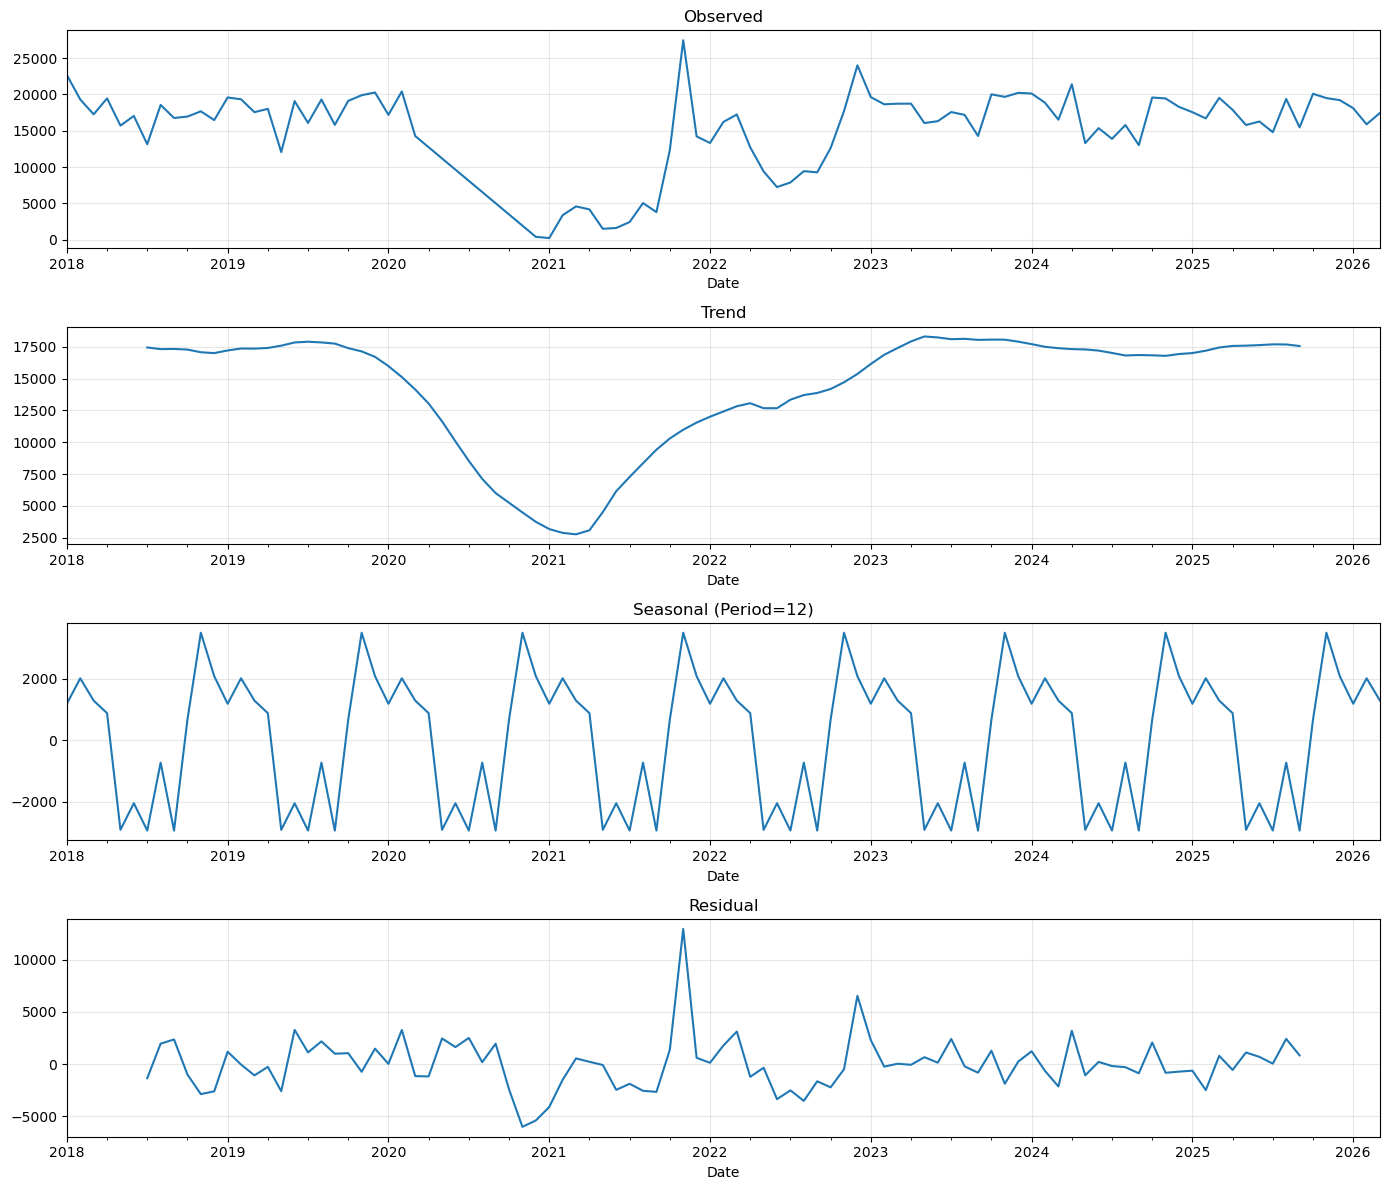

Seasonal decomposition confirms:
  - Strong upward trend pre-COVID
  - Clear 12-month seasonal pattern (Dec-Mar peaks)
  - Residuals amplified during crisis periods


In [8]:
# Only use non-zero months for decomposition (COVID zeros distort it)
monthly_nonzero = monthly.copy()
monthly_nonzero[monthly_nonzero == 0] = np.nan
monthly_nonzero = monthly_nonzero.interpolate(method='linear')

decomposition = seasonal_decompose(monthly_nonzero, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal (Period=12)')
decomposition.resid.plot(ax=axes[3], title='Residual')
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/00_decomposition.png', dpi=150)
plt.show()
print("Seasonal decomposition confirms:")
print("  - Strong upward trend pre-COVID")
print("  - Clear 12-month seasonal pattern (Dec-Mar peaks)")
print("  - Residuals amplified during crisis periods")

## Step 8: Train/test split

TRAIN/TEST SPLIT:
  Train: 2018-01-31 to 2024-12-31 (84 months)
  Test:  2025-01-31  to 2026-03-31  (15 months)
  Split: 84.8% train / 15.2% test

NOTE: Random splitting is NOT used for time series.
Using random split would cause data leakage — future data in training.


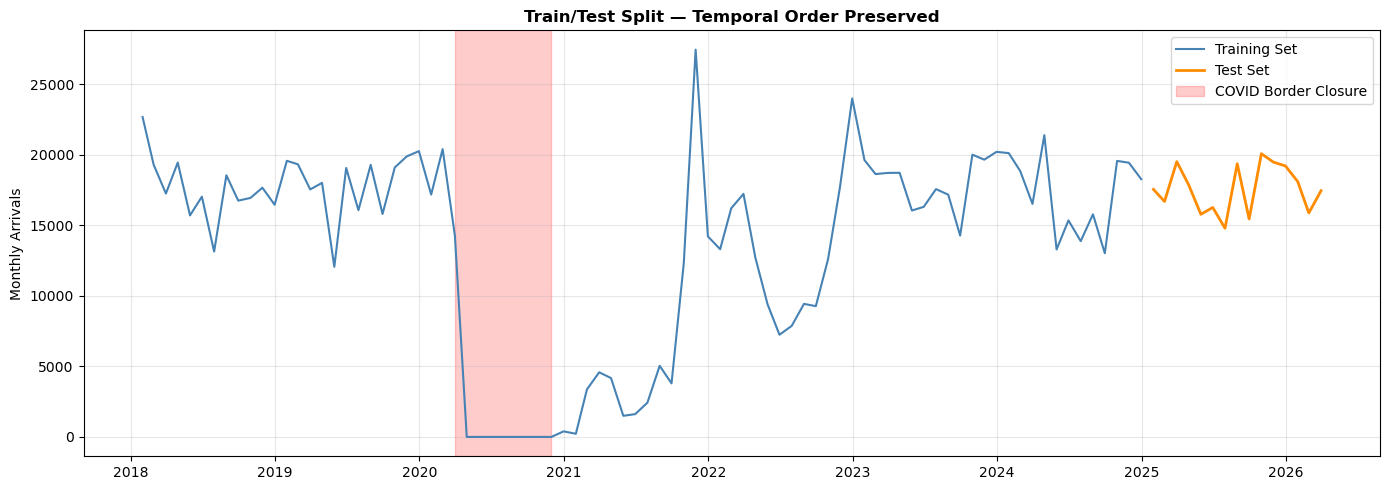

In [9]:
# Temporal split — NEVER random split for time series
# Train: Jan 2018 to Dec 2024 (84 months)
# Test:  Jan 2025 to Mar 2026 (15 months)

train = monthly[monthly.index < '2025-01-01']
test  = monthly[monthly.index >= '2025-01-01']

print("TRAIN/TEST SPLIT:")
print(f"  Train: {train.index.min().date()} to {train.index.max().date()} ({len(train)} months)")
print(f"  Test:  {test.index.min().date()}  to {test.index.max().date()}  ({len(test)} months)")
print(f"  Split: {len(train)/(len(train)+len(test))*100:.1f}% train / {len(test)/(len(train)+len(test))*100:.1f}% test")
print()
print("NOTE: Random splitting is NOT used for time series.")
print("Using random split would cause data leakage — future data in training.")

# Plot train/test split
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train.values, label='Training Set', color='steelblue')
ax.plot(test.index, test.values, label='Test Set', color='darkorange', linewidth=2)
ax.axvspan(pd.Timestamp('2020-04-01'), pd.Timestamp('2020-11-30'),
           alpha=0.2, color='red', label='COVID Border Closure')
ax.set_title('Train/Test Split — Temporal Order Preserved', fontweight='bold')
ax.set_ylabel('Monthly Arrivals')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/00_train_test_split.png', dpi=150)
plt.show()

## Step 9: Feature engineering for ML models

In [10]:
# Feature engineering — creates the input features for XGBoost
# All features derived from the time series itself (no external data needed)

def make_features(series):
    d = pd.DataFrame({'y': series})
    
    # Lag features — past arrival values
    for lag in [1, 2, 3, 6, 12]:
        d[f'lag{lag}'] = d['y'].shift(lag)
        
    # Rolling mean features — capture recent momentum
    # shift(1) prevents leakage: we only use values we already know
    d['rm3'] = d['y'].shift(1).rolling(3).mean()
    d['rm6'] = d['y'].shift(1).rolling(6).mean()
    
    # Calendar features — encode seasonality explicitly for ML
    d['month']   = d.index.month
    d['quarter'] = d.index.quarter
    
    return d

fd = make_features(monthly)
print("Features created:")
print(list(fd.columns[1:]))  # exclude 'y'
print(f"\nRows before dropna: {len(fd)}")
fd = fd.dropna()
print(f"Rows after dropna:  {len(fd)} (removed first 12 due to lag12)")
print()
print("Feature correlation with target (arrivals):")
print(fd.corr()['y'].sort_values(ascending=False).round(3))

Features created:
['lag1', 'lag2', 'lag3', 'lag6', 'lag12', 'rm3', 'rm6', 'month', 'quarter']

Rows before dropna: 99
Rows after dropna:  87 (removed first 12 due to lag12)

Feature correlation with target (arrivals):
y          1.000
lag1       0.843
rm3        0.799
lag2       0.741
rm6        0.697
lag3       0.655
lag6       0.377
lag12      0.272
quarter    0.004
month      0.002
Name: y, dtype: float64


## Step 10: Save preprocessed data and summary

In [11]:
# Save cleaned monthly series
monthly.to_frame('Arrivals').to_csv('../data/monthly_total_arrivals.csv')

# Print preprocessing summary
print("=" * 60)
print("PREPROCESSING SUMMARY")
print("=" * 60)
print(f"Raw dataset rows:          {df.shape[0]}")
print(f"Countries:                 {df_clean['Country'].nunique()}")
print(f"Monthly total series:      {len(monthly)} months")
print(f"Date range:                Jan 2018 to Mar 2026")
print(f"COVID months (zero):       8 months (Apr-Nov 2020)")
print(f"Null values remaining:     {monthly.isnull().sum()}")
print(f"Train size:                {len(train)} months")
print(f"Test size:                 {len(test)} months")
print(f"ADF p-value (original):    {result[1]:.4f} — non-stationary")
print(f"ADF p-value (differenced): {result2[1]:.4f} — stationary")
print(f"Seasonal period:           12 months (confirmed by decomposition)")
print(f"ML features engineered:    9 (5 lags + 2 rolling means + month + quarter)")
print("=" * 60)
print("\nPreprocessed data saved to: ../data/monthly_total_arrivals.csv")
print("Decomposition plot saved to: ../results/00_decomposition.png")
print("Train-test split plot saved to: ../results/00_train_test_split.png")
print("\nPreprocessing complete. Proceed to 02_baseline_models.ipynb")

PREPROCESSING SUMMARY
Raw dataset rows:          20472
Countries:                 215
Monthly total series:      99 months
Date range:                Jan 2018 to Mar 2026
COVID months (zero):       8 months (Apr-Nov 2020)
Null values remaining:     0
Train size:                84 months
Test size:                 15 months
ADF p-value (original):    0.0337 — non-stationary
ADF p-value (differenced): 0.0000 — stationary
Seasonal period:           12 months (confirmed by decomposition)
ML features engineered:    9 (5 lags + 2 rolling means + month + quarter)

Preprocessed data saved to: ../data/monthly_total_arrivals.csv
Decomposition plot saved to: ../results/00_decomposition.png
Train-test split plot saved to: ../results/00_train_test_split.png

Preprocessing complete. Proceed to 02_baseline_models.ipynb
